In [1]:
%gui qt
%load_ext autoreload
%autoreload 2

In [2]:
import napari
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import napari
from sklearn.cluster import DBSCAN
import hmt_functions as hmt

In [3]:
me3_raw_df = pd.read_csv("test_data/k27_k27_thaw009_me3.csv")
ac_raw_df = pd.read_csv("test_data/k27_k27_thaw009_ac.csv")

In [4]:
me3_filtered_df = hmt.filter_axial(me3_raw_df)
ac_filtered_df = hmt.filter_axial(ac_raw_df)

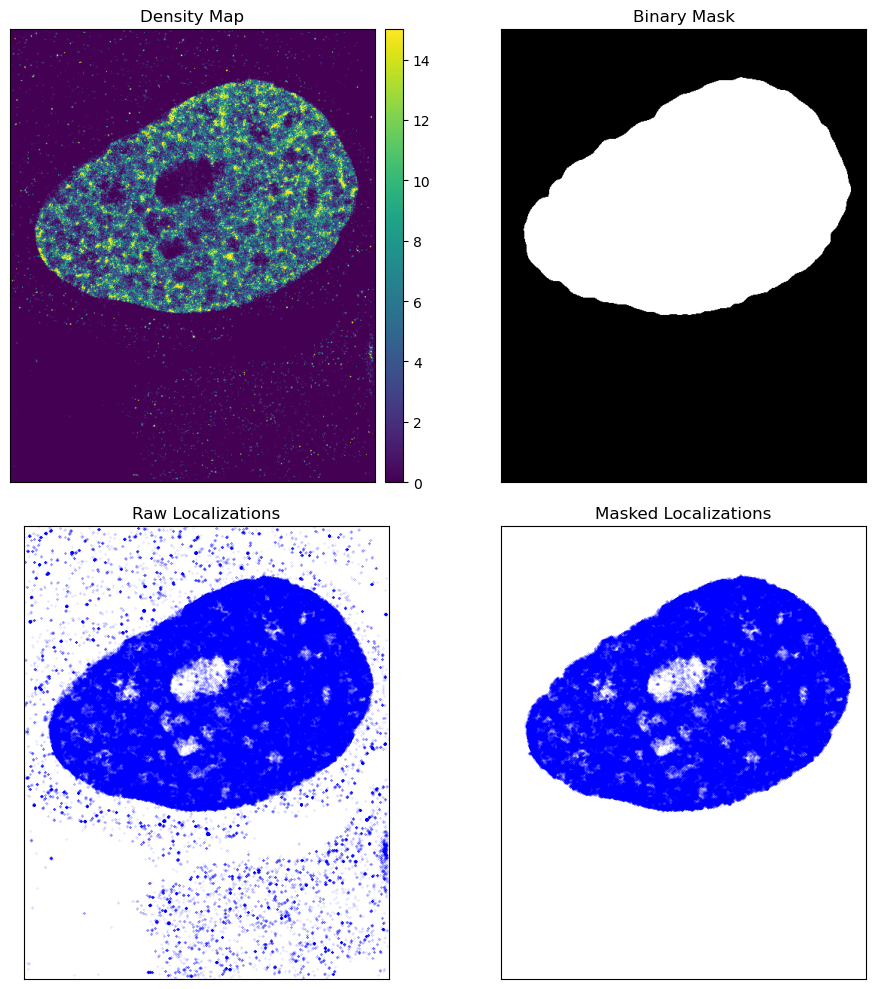

In [5]:
binary_mask, me3_df, ac_df = hmt.binarize_nucleus(me3_filtered_df, ac_filtered_df, thresh=2, show_plots=True)

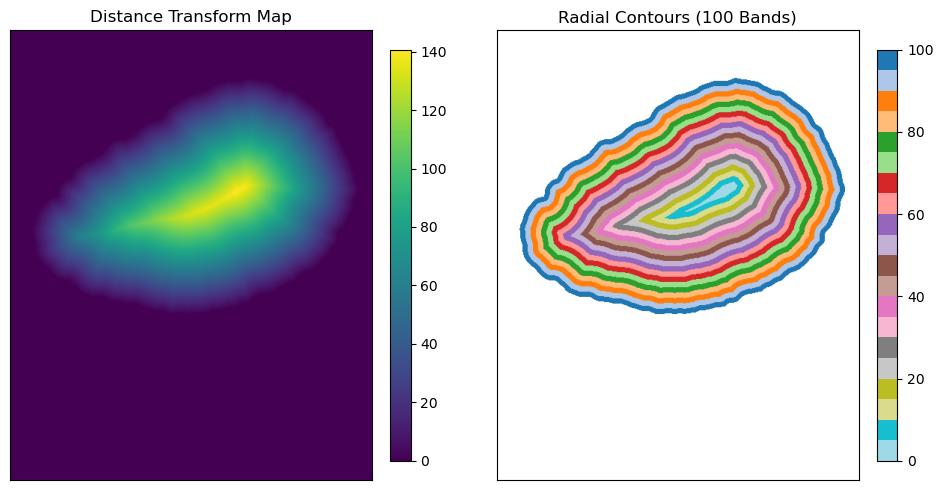

In [6]:
distance_map, contour_bands = hmt.create_radial_contours(binary_mask, show_plots=True)

In [11]:
hmt.cluster_dbscan(me3_df, eps=50)
hmt.cluster_dbscan(ac_df, eps=55)

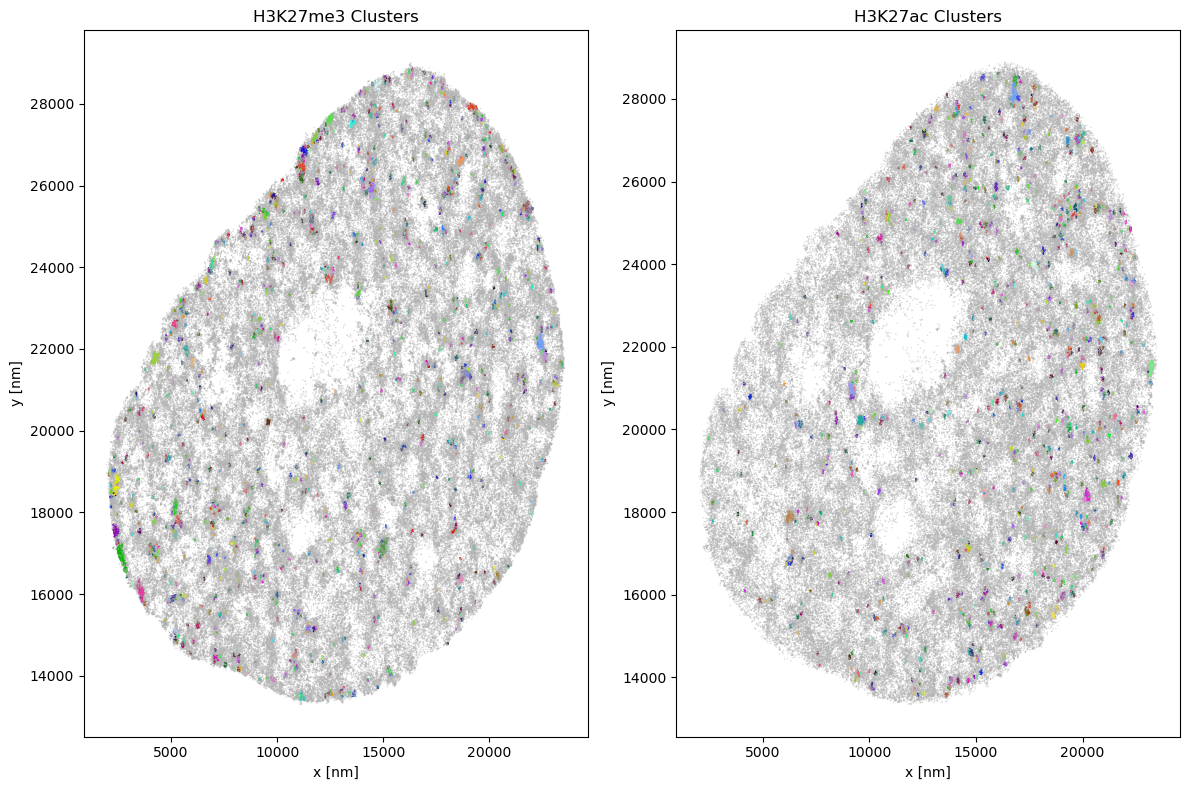

In [12]:
plt.figure(figsize=(12,8))
plt.subplot(1, 2, 1)
plt.scatter(data=me3_df, x="x [nm]", y="y [nm]", c="cluster_color", s=1, linewidths=0)
plt.xlabel("x [nm]")
plt.ylabel("y [nm]")
plt.title("H3K27me3 Clusters")

plt.subplot(1, 2, 2)
plt.scatter(data=ac_df, x="x [nm]", y="y [nm]", c="cluster_color", s=1, linewidths=0)
plt.xlabel("x [nm]")
plt.ylabel("y [nm]")
plt.title("H3K27ac Clusters")

plt.tight_layout()
plt.show()

In [10]:
hmt.plot_clusters_napari(me3_df, ac_df)
